# MLP hyperparameter search

Local random search for dense MLP architectures. This notebook saves CSV files under `data/mlp_search/` and does not publish runs or artifacts to any tracking server.

Search strategy:

1. Sample a focused set of MLP configurations.
2. Rank candidates on validation MAE only using representative input/output windows.
3. Evaluate the top candidates across all 16 windows and selected seeds.
4. Compare the final candidates against the already saved MLP CSV results.

The test split is only evaluated in the final stage.

In [1]:
from __future__ import annotations

import itertools
import sys
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras import regularizers
from keras.callbacks import EarlyStopping
from keras.layers import Activation, BatchNormalization, Dense, Dropout, Input
from keras.models import Sequential
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import ParameterSampler


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in [start, *start.parents]:
        if (candidate / "util.py").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing util.py")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from util import RANDOM_SEED, get_train_test

PROJECT_ROOT

PosixPath('/Users/jchulvi/projects/Neural-Networks-Forecasting')

## Search configuration

`QUICK_MODE=True` keeps the first run manageable. Set it to `False` when you want a broader search.

In [2]:
RESULTS_DIR = PROJECT_ROOT / "data" / "mlp_search"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_WINDOWS = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]
FULL_WINDOWS = list(itertools.product(INPUT_WINDOWS, OUTPUT_WINDOWS))

# Representative windows for choosing candidate configs before using test.
SEARCH_WINDOWS = [
    (90, 1),
    (90, 5),
    (30, 90),
    (10, 5),
]

QUICK_MODE = True

MODE_LABEL = "quick" if QUICK_MODE else "full"

N_ITER = 12 if QUICK_MODE else 40
TOP_K = 4 if QUICK_MODE else 8
STAGE1_SEEDS = [RANDOM_SEED]
FINAL_SEEDS = [RANDOM_SEED] if QUICK_MODE else [42, 123, 777]

EPOCHS = 500
PATIENCE = 20
MIN_DELTA = 1e-6
VALIDATION_FRACTION = 0.10
VERBOSE = 0

SEARCH_SPACE = {
    "hidden_layers": [1, 2, 3, 4],
    "neurons": [32, 64, 100, 128, 200, 256],
    "activation": ["relu", "gelu", "tanh", "elu"],
    "dropout_rate": [0.0, 0.05, 0.10, 0.20, 0.30],
    "l2": [0.0, 1e-6, 1e-5, 1e-4],
    "learning_rate": [1e-4, 3e-4, 1e-3, 3e-3],
    "batch_size": [64, 128, 256],
    "batch_norm": [False, True],
}

print(f"Stage 1 runs: {N_ITER * len(SEARCH_WINDOWS) * len(STAGE1_SEEDS)}")
print(f"Final runs:   {TOP_K * len(FULL_WINDOWS) * len(FINAL_SEEDS)}")
print(f"CSV output:   {RESULTS_DIR}")
print(f"Mode label:   {MODE_LABEL}")

Stage 1 runs: 48
Final runs:   64
CSV output:   /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mlp_search
Mode label:   quick


## Helpers

The validation split is carved from the end of the training period. Test data is held out until the final stage.

In [3]:
WINDOW_CACHE: dict[tuple[int, int, float], dict[str, np.ndarray]] = {}


def to_python_scalar(value):
    if isinstance(value, np.generic):
        return value.item()
    return value


def parse_bool(value) -> bool:
    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}
    return bool(value)


def normalize_config(config: dict) -> dict:
    cfg = {key: to_python_scalar(value) for key, value in config.items()}
    cfg["hidden_layers"] = int(cfg["hidden_layers"])
    cfg["neurons"] = int(cfg["neurons"])
    cfg["dropout_rate"] = float(cfg["dropout_rate"])
    cfg["l2"] = float(cfg["l2"])
    cfg["learning_rate"] = float(cfg["learning_rate"])
    cfg["batch_size"] = int(cfg["batch_size"])
    cfg["batch_norm"] = parse_bool(cfg["batch_norm"])
    return cfg


def compact_float(value: float) -> str:
    if value == 0:
        return "0"
    return f"{value:.0e}".replace("-", "m")


def make_config_name(config: dict) -> str:
    bn = "bn" if config["batch_norm"] else "nobn"
    dropout = str(config["dropout_rate"]).replace(".", "p")
    return (
        f"mlp_{config['hidden_layers']}x{config['neurons']}_"
        f"{config['activation']}_drop{dropout}_"
        f"l2{compact_float(config['l2'])}_"
        f"lr{compact_float(config['learning_rate'])}_"
        f"bs{config['batch_size']}_{bn}"
    )


def sample_configs(search_space: dict, n_iter: int, random_state: int) -> list[dict]:
    sampler = ParameterSampler(search_space, n_iter=n_iter, random_state=random_state)
    configs = []
    for idx, raw_config in enumerate(sampler, start=1):
        config = normalize_config(raw_config)
        config["config_id"] = f"cfg_{idx:03d}"
        config["config_name"] = make_config_name(config)
        configs.append(config)
    return configs


def get_window_split(
    input_window: int,
    output_window: int,
    validation_fraction: float = VALIDATION_FRACTION,
) -> dict[str, np.ndarray]:
    key = (input_window, output_window, validation_fraction)
    if key in WINDOW_CACHE:
        return WINDOW_CACHE[key]

    data = get_train_test(input_window_size=input_window, output_window_size=output_window)
    X_train_full = data.X_train.reshape(data.X_train.shape[0], -1)
    X_test = data.X_test.reshape(data.X_test.shape[0], -1)

    n_val = max(1, int(round(len(X_train_full) * validation_fraction)))
    split_at = len(X_train_full) - n_val
    if split_at <= 0:
        raise ValueError("Validation fraction leaves no training rows")

    split = {
        "X_train": X_train_full[:split_at],
        "y_train": data.y_train[:split_at],
        "X_val": X_train_full[split_at:],
        "y_val": data.y_train[split_at:],
        "X_test": X_test,
        "y_test": data.y_test,
    }
    WINDOW_CACHE[key] = split
    return split


def build_mlp(input_dim: int, output_dim: int, config: dict) -> Sequential:
    keras.backend.clear_session()

    model = Sequential(name=config["config_id"])
    model.add(Input(shape=(input_dim,)))

    reg = regularizers.l2(config["l2"]) if config["l2"] > 0 else None
    for _ in range(config["hidden_layers"]):
        if config["batch_norm"]:
            model.add(Dense(config["neurons"], use_bias=False, kernel_regularizer=reg))
            model.add(BatchNormalization())
            model.add(Activation(config["activation"]))
        else:
            model.add(
                Dense(
                    config["neurons"],
                    activation=config["activation"],
                    kernel_regularizer=reg,
                )
            )

        if config["dropout_rate"] > 0:
            model.add(Dropout(config["dropout_rate"]))

    model.add(Dense(output_dim))
    model.compile(
        optimizer=Adam(learning_rate=config["learning_rate"]),
        loss="mae",
    )
    return model


def fit_one(
    config: dict,
    input_window: int,
    output_window: int,
    seed: int,
    evaluate_test: bool,
) -> dict:
    split = get_window_split(input_window, output_window)
    keras.utils.set_random_seed(seed)

    model = build_mlp(
        input_dim=split["X_train"].shape[1],
        output_dim=split["y_train"].shape[1],
        config=config,
    )
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        restore_best_weights=True,
    )

    history = model.fit(
        split["X_train"],
        split["y_train"],
        validation_data=(split["X_val"], split["y_val"]),
        epochs=EPOCHS,
        batch_size=config["batch_size"],
        callbacks=[early_stop],
        verbose=VERBOSE,
    )

    val_history = np.asarray(history.history["val_loss"], dtype=float)
    train_pred = model.predict(split["X_train"], verbose=0)
    val_pred = model.predict(split["X_val"], verbose=0)

    row = {
        "config_id": config["config_id"],
        "config_name": config["config_name"],
        "input_window": input_window,
        "output_window": output_window,
        "seed": seed,
        "hidden_layers": config["hidden_layers"],
        "neurons": config["neurons"],
        "activation": config["activation"],
        "dropout_rate": config["dropout_rate"],
        "l2": config["l2"],
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],
        "batch_norm": config["batch_norm"],
        "MAE_train": mean_absolute_error(split["y_train"], train_pred),
        "MAE_val": mean_absolute_error(split["y_val"], val_pred),
        "epochs": len(history.history["loss"]),
        "best_epoch": int(val_history.argmin() + 1),
        "best_history_val_loss": float(val_history.min()),
        "final_history_val_loss": float(val_history[-1]),
        "n_params": model.count_params(),
        "train_rows": split["X_train"].shape[0],
        "val_rows": split["X_val"].shape[0],
        "test_rows": split["X_test"].shape[0],
    }

    if evaluate_test:
        test_pred = model.predict(split["X_test"], verbose=0)
        row["MAE_test"] = mean_absolute_error(split["y_test"], test_pred)

    return row


def run_configs(
    configs: list[dict],
    windows: list[tuple[int, int]],
    seeds: list[int],
    evaluate_test: bool,
    result_path: Path,
) -> pd.DataFrame:
    rows = []
    total = len(configs) * len(windows) * len(seeds)

    for run_idx, (config, (input_window, output_window), seed) in enumerate(
        itertools.product(configs, windows, seeds),
        start=1,
    ):
        print(
            f"[{run_idx:>4}/{total}] {config['config_id']} "
            f"in={input_window} out={output_window} seed={seed}",
            flush=True,
        )
        rows.append(
            fit_one(
                config=config,
                input_window=input_window,
                output_window=output_window,
                seed=seed,
                evaluate_test=evaluate_test,
            )
        )

        if run_idx % 5 == 0:
            pd.DataFrame(rows).to_csv(result_path, index=False)

    results = pd.DataFrame(rows)
    results.to_csv(result_path, index=False)
    return results


def summarize_by_config(results: pd.DataFrame) -> pd.DataFrame:
    group_cols = [
        "config_id",
        "config_name",
        "hidden_layers",
        "neurons",
        "activation",
        "dropout_rate",
        "l2",
        "learning_rate",
        "batch_size",
        "batch_norm",
    ]

    agg = {
        "MAE_val": ["mean", "median", "std", "min", "max"],
        "MAE_train": ["mean"],
        "epochs": ["mean", "max"],
        "best_epoch": ["mean"],
        "n_params": ["mean"],
        "config_id": ["size"],
    }
    if "MAE_test" in results.columns:
        agg["MAE_test"] = ["mean", "median", "std", "min", "max"]

    summary = results.groupby(group_cols, dropna=False).agg(agg)
    summary.columns = ["_".join(col).strip("_") for col in summary.columns]
    summary = summary.rename(
        columns={
            "config_id_size": "n_runs",
            "MAE_val_mean": "mean_val",
            "MAE_val_median": "median_val",
            "MAE_val_std": "std_val",
            "MAE_val_min": "best_val",
            "MAE_val_max": "worst_val",
            "MAE_train_mean": "mean_train",
            "epochs_mean": "mean_epochs",
            "epochs_max": "max_epochs",
            "best_epoch_mean": "mean_best_epoch",
            "n_params_mean": "mean_params",
            "MAE_test_mean": "mean_test",
            "MAE_test_median": "median_test",
            "MAE_test_std": "std_test",
            "MAE_test_min": "best_test",
            "MAE_test_max": "worst_test",
        }
    ).reset_index()

    sort_cols = ["mean_test", "mean_val"] if "mean_test" in summary.columns else ["mean_val"]
    return summary.sort_values(sort_cols).reset_index(drop=True)


def select_configs(summary: pd.DataFrame, top_k: int) -> list[dict]:
    selected = []
    config_cols = [
        "hidden_layers",
        "neurons",
        "activation",
        "dropout_rate",
        "l2",
        "learning_rate",
        "batch_size",
        "batch_norm",
    ]
    for _, row in summary.head(top_k).iterrows():
        config = normalize_config({col: row[col] for col in config_cols})
        config["config_id"] = row["config_id"]
        config["config_name"] = row.get("config_name", make_config_name(config))
        selected.append(config)
    return selected


def load_if_complete(
    result_path: Path,
    expected_rows: int,
    required_columns: list[str],
) -> pd.DataFrame | None:
    if not result_path.exists():
        return None

    results = pd.read_csv(result_path)
    missing_columns = [col for col in required_columns if col not in results.columns]
    is_complete = len(results) == expected_rows and not missing_columns
    if is_complete:
        print(f"Loaded complete cached results from {result_path}")
        return results

    print(
        f"Ignoring incomplete cached results at {result_path}: "
        f"rows={len(results)}, expected={expected_rows}, "
        f"missing_columns={missing_columns}"
    )
    return None


def best_by_window(results: pd.DataFrame, metric: str = "MAE_test") -> pd.DataFrame:
    idx = results.groupby(["input_window", "output_window"])[metric].idxmin()
    return results.loc[idx].sort_values(["input_window", "output_window"]).reset_index(drop=True)

## Stage 1: representative-window random search

This stage ranks configs by validation MAE only. It does not evaluate test MAE.

In [4]:
sampled_configs = sample_configs(SEARCH_SPACE, n_iter=N_ITER, random_state=RANDOM_SEED)
pd.DataFrame(sampled_configs).head()

,neurons,learning_rate,l2,hidden_layers,dropout_rate,batch_size,batch_norm,activation,config_id,config_name
0,128,0.0001,0.000010,1,0.05,256,False,gelu,cfg_001,mlp_1x128_gelu_drop0p05_l21em05_lr1em04_bs256_...
1,100,0.0030,0.000100,1,0.10,64,False,relu,cfg_002,mlp_1x100_relu_drop0p1_l21em04_lr3em03_bs64_nobn
2,200,0.0030,0.000001,2,0.30,128,False,elu,cfg_003,mlp_2x200_elu_drop0p3_l21em06_lr3em03_bs128_nobn
3,100,0.0030,0.000100,2,0.05,256,True,elu,cfg_004,mlp_2x100_elu_drop0p05_l21em04_lr3em03_bs256_bn
4,200,0.0001,0.000010,2,0.30,256,True,relu,cfg_005,mlp_2x200_relu_drop0p3_l21em05_lr1em04_bs256_bn


In [5]:
stage1_path = RESULTS_DIR / f"mlp_random_search_stage1_{MODE_LABEL}.csv"
stage1_expected_rows = len(sampled_configs) * len(SEARCH_WINDOWS) * len(STAGE1_SEEDS)

stage1_results = load_if_complete(
    result_path=stage1_path,
    expected_rows=stage1_expected_rows,
    required_columns=["MAE_val"],
)
if stage1_results is None:
    stage1_results = run_configs(
        configs=sampled_configs,
        windows=SEARCH_WINDOWS,
        seeds=STAGE1_SEEDS,
        evaluate_test=False,
        result_path=stage1_path,
    )

stage1_results.head()

Loaded complete cached results from /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mlp_search/mlp_random_search_stage1_quick.csv


,config_id,config_name,input_window,output_window,seed,hidden_layers,neurons,activation,dropout_rate,l2,...,MAE_train,MAE_val,epochs,best_epoch,best_history_val_loss,final_history_val_loss,n_params,train_rows,val_rows,test_rows
0,cfg_001,mlp_1x128_gelu_drop0p05_l21em05_lr1em04_bs256_...,90,1,42,1,128,gelu,0.05,0.00001,...,0.010520,0.009930,226,224,0.010099,0.010099,268055,13037,1448,1610
1,cfg_001,mlp_1x128_gelu_drop0p05_l21em05_lr1em04_bs256_...,90,5,42,1,128,gelu,0.05,0.00001,...,0.004843,0.004550,248,232,0.004619,0.004621,268055,13033,1448,1610
2,cfg_001,mlp_1x128_gelu_drop0p05_l21em05_lr1em04_bs256_...,30,90,42,1,128,gelu,0.05,0.00001,...,0.001220,0.000949,220,219,0.000956,0.000957,91415,13013,1446,1607
3,cfg_001,mlp_1x128_gelu_drop0p05_l21em05_lr1em04_bs256_...,10,5,42,1,128,gelu,0.05,0.00001,...,0.005383,0.004199,298,298,0.004211,0.004211,32535,13098,1455,1618
4,cfg_002,mlp_1x100_relu_drop0p1_l21em04_lr3em03_bs64_nobn,90,1,42,1,100,relu,0.10,0.00010,...,0.011954,0.009121,21,1,0.009121,0.009158,209423,13037,1448,1610


In [6]:
stage1_summary = summarize_by_config(stage1_results)
stage1_summary.head(TOP_K)

,config_id,config_name,hidden_layers,neurons,activation,dropout_rate,l2,learning_rate,batch_size,batch_norm,...,median_val,std_val,best_val,worst_val,mean_train,mean_epochs,max_epochs,mean_best_epoch,mean_params,n_runs
0,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,3,128,gelu,0.05,0.000100,0.0010,256,False,...,0.004153,0.003347,0.000936,0.009047,0.006024,56.50,66,39.50,198039.0,4
1,cfg_010,mlp_4x64_elu_drop0p3_l21em05_lr3em03_bs128_bn,4,64,elu,0.30,0.000010,0.0030,128,True,...,0.004210,0.003344,0.000966,0.009075,0.006058,103.00,127,84.75,95767.0,4
2,cfg_007,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn,4,100,gelu,0.20,0.000010,0.0001,256,False,...,0.004182,0.003422,0.000931,0.009216,0.005899,106.75,126,97.00,159223.0,4
3,cfg_006,mlp_2x64_relu_drop0p05_l21em06_lr1em04_bs64_bn,2,64,relu,0.05,0.000001,0.0001,64,True,...,0.004197,0.003378,0.000977,0.009158,0.005894,103.00,171,83.50,87063.0,4


## Stage 2: final evaluation across all windows

Only the top validation-ranked configs from Stage 1 are evaluated on the test split.

In [7]:
top_configs = select_configs(stage1_summary, top_k=TOP_K)
pd.DataFrame(top_configs)

,hidden_layers,neurons,activation,dropout_rate,l2,learning_rate,batch_size,batch_norm,config_id,config_name
0,3,128,gelu,0.05,0.000100,0.0010,256,False,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...
1,4,64,elu,0.30,0.000010,0.0030,128,True,cfg_010,mlp_4x64_elu_drop0p3_l21em05_lr3em03_bs128_bn
2,4,100,gelu,0.20,0.000010,0.0001,256,False,cfg_007,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn
3,2,64,relu,0.05,0.000001,0.0001,64,True,cfg_006,mlp_2x64_relu_drop0p05_l21em06_lr1em04_bs64_bn


In [8]:
final_path = RESULTS_DIR / f"mlp_random_search_final_{MODE_LABEL}.csv"
final_expected_rows = len(top_configs) * len(FULL_WINDOWS) * len(FINAL_SEEDS)

final_results = load_if_complete(
    result_path=final_path,
    expected_rows=final_expected_rows,
    required_columns=["MAE_val", "MAE_test"],
)
if final_results is None:
    final_results = run_configs(
        configs=top_configs,
        windows=FULL_WINDOWS,
        seeds=FINAL_SEEDS,
        evaluate_test=True,
        result_path=final_path,
    )

final_results.head()

Loaded complete cached results from /Users/jchulvi/projects/Neural-Networks-Forecasting/data/mlp_search/mlp_random_search_final_quick.csv


,config_id,config_name,input_window,output_window,seed,hidden_layers,neurons,activation,dropout_rate,l2,...,MAE_val,epochs,best_epoch,best_history_val_loss,final_history_val_loss,n_params,train_rows,val_rows,test_rows,MAE_test
0,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,5,1,42,3,128,gelu,0.05,0.0001,...,0.009035,30,10,0.009035,0.009046,50839,13106,1456,1618,0.012231
1,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,5,5,42,3,128,gelu,0.05,0.0001,...,0.004168,40,20,0.004168,0.004171,50839,13102,1456,1618,0.005592
2,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,5,30,42,3,128,gelu,0.05,0.0001,...,0.001710,33,13,0.001710,0.001721,50839,13081,1454,1616,0.002338
3,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,5,90,42,3,128,gelu,0.05,0.0001,...,0.000937,42,22,0.000937,0.000953,50839,13033,1448,1610,0.001263
4,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,10,1,42,3,128,gelu,0.05,0.0001,...,0.009031,35,15,0.009031,0.009048,65559,13101,1456,1618,0.012230


In [9]:
final_summary = summarize_by_config(final_results)
final_summary

,config_id,config_name,hidden_layers,neurons,activation,dropout_rate,l2,learning_rate,batch_size,batch_norm,...,mean_epochs,max_epochs,mean_best_epoch,mean_params,n_runs,mean_test,median_test,std_test,best_test,worst_test
0,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,3,128,gelu,0.05,0.000100,0.0010,256,False,...,48.2500,84,29.0625,135479.0,16,0.005359,0.003968,0.004420,0.001263,0.012258
1,cfg_007,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn,4,100,gelu,0.20,0.000010,0.0001,256,False,...,99.1250,126,88.3750,110348.0,16,0.005376,0.003954,0.004449,0.001262,0.012459
2,cfg_010,mlp_4x64_elu_drop0p3_l21em05_lr3em03_bs128_bn,4,64,elu,0.30,0.000010,0.0030,128,True,...,96.3125,127,76.7500,64487.0,16,0.005384,0.003992,0.004425,0.001276,0.012282
3,cfg_006,mlp_2x64_relu_drop0p05_l21em06_lr1em04_bs64_bn,2,64,relu,0.05,0.000001,0.0001,64,True,...,118.0000,202,100.3750,55783.0,16,0.005427,0.003998,0.004446,0.001290,0.012465


In [10]:
best_final = best_by_window(final_results, metric="MAE_test")
best_final[[
    "input_window",
    "output_window",
    "config_id",
    "config_name",
    "seed",
    "MAE_val",
    "MAE_test",
    "epochs",
    "n_params",
]]

,input_window,output_window,config_id,config_name,seed,MAE_val,MAE_test,epochs,n_params
0,5,1,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,42,0.009035,0.012231,30,50839
1,5,5,cfg_007,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn,42,0.004154,0.005575,95,44223
2,5,30,cfg_007,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn,42,0.001705,0.002326,96,44223
3,5,90,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,42,0.000937,0.001263,42,50839
4,10,1,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,42,0.009031,0.012230,35,65559
5,10,5,cfg_007,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn,42,0.004149,0.005577,91,55723
6,10,30,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,42,0.001718,0.002322,44,65559
7,10,90,cfg_007,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn,42,0.000929,0.001262,104,55723
8,30,1,cfg_011,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,42,0.009041,0.012243,47,124439
9,30,5,cfg_007,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn,42,0.004145,0.005585,85,101723


## Compare against saved MLP baselines

This comparison uses the existing CSV files under `data/mlp/` and the final local-search CSV above.

In [11]:
def load_existing_mlp_results() -> pd.DataFrame:
    rows = []
    for path in sorted((PROJECT_ROOT / "data" / "mlp").glob("*.csv")):
        if path.name.endswith("_history.csv"):
            continue
        rows.append(pd.read_csv(path))
    existing = pd.concat(rows, ignore_index=True)
    existing["source"] = "saved_baseline"
    return existing


existing_results = load_existing_mlp_results()
existing_summary = (
    existing_results.groupby("model_name")
    .agg(
        mean_test=("MAE_test", "mean"),
        median_test=("MAE_test", "median"),
        best_test=("MAE_test", "min"),
        worst_test=("MAE_test", "max"),
        mean_val=("MAE_val", "mean"),
        mean_params=("n_params", "mean"),
        n_runs=("model_name", "size"),
    )
    .reset_index()
    .rename(columns={"model_name": "name"})
)
existing_summary["source"] = "saved_baseline"

search_summary = final_summary.rename(columns={"config_name": "name"})[
    ["name", "mean_test", "median_test", "best_test", "worst_test", "mean_val", "mean_params", "n_runs"]
]
search_summary["source"] = "local_search"

combined_summary = pd.concat([search_summary, existing_summary], ignore_index=True)
combined_summary.sort_values("mean_test").reset_index(drop=True)

,name,mean_test,median_test,best_test,worst_test,mean_val,mean_params,n_runs,source
0,mlp_3x128_gelu_drop0p05_l21em04_lr1em03_bs256_...,0.005359,0.003968,0.001263,0.012258,0.003961,135479.0,16,local_search
1,mlp_4x100_gelu_drop0p2_l21em05_lr1em04_bs256_nobn,0.005376,0.003954,0.001262,0.012459,0.003972,110348.0,16,local_search
2,mlp_4x64_elu_drop0p3_l21em05_lr3em03_bs128_bn,0.005384,0.003992,0.001276,0.012282,0.003989,64487.0,16,local_search
3,mlp_2x64_relu_drop0p05_l21em06_lr1em04_bs64_bn,0.005427,0.003998,0.001290,0.012465,0.003991,55783.0,16,local_search
4,mlp_2x100_dropout,0.005618,0.004121,0.001387,0.012971,0.003995,90148.0,16,saved_baseline
5,mlp_3x200_relu,0.006165,0.004479,0.001373,0.014438,0.003992,240473.0,16,saved_baseline
6,mlp_2x100_relu,0.006678,0.004705,0.001425,0.015833,0.003998,90148.0,16,saved_baseline
7,mlp_1x64_relu,0.006862,0.004597,0.001483,0.016718,0.004002,51239.0,16,saved_baseline
8,mlp_1x100_relu,0.006970,0.004950,0.001611,0.017497,0.004004,80048.0,16,saved_baseline
9,mlp_2x100_bn_l2,0.019015,0.008115,0.002770,0.140086,0.005333,90948.0,16,saved_baseline


## Visual checks

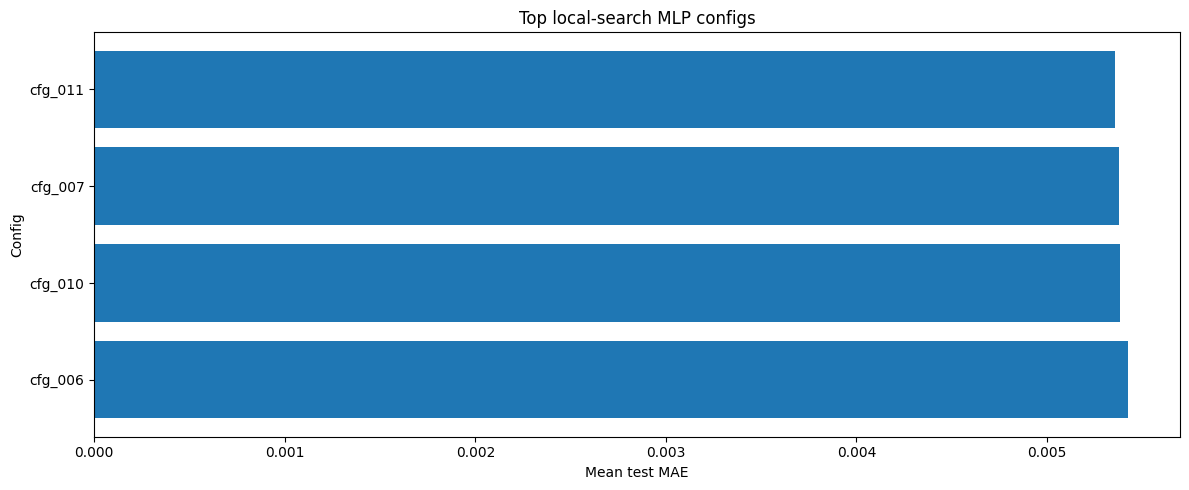

In [12]:
plot_df = final_summary.head(15).copy()
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(plot_df["config_id"], plot_df["mean_test"])
ax.invert_yaxis()
ax.set_xlabel("Mean test MAE")
ax.set_ylabel("Config")
ax.set_title("Top local-search MLP configs")
plt.tight_layout()
plt.show()

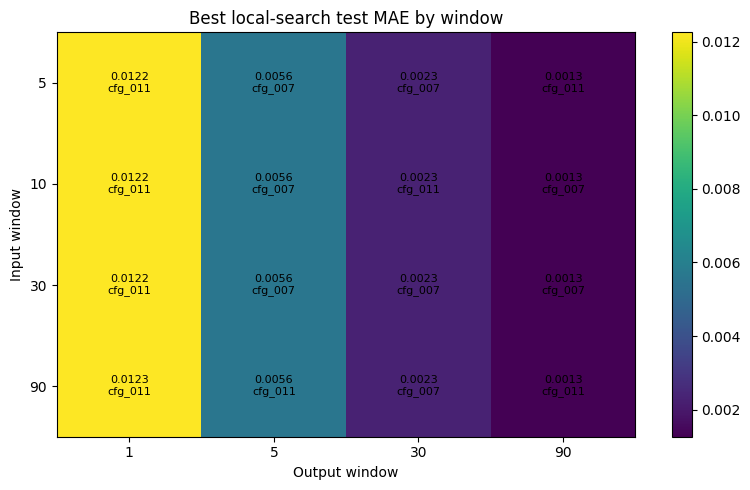

In [13]:
mae_matrix = best_final.pivot(index="input_window", columns="output_window", values="MAE_test")
name_matrix = best_final.pivot(index="input_window", columns="output_window", values="config_id")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(mae_matrix.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(mae_matrix.columns)))
ax.set_xticklabels(mae_matrix.columns)
ax.set_yticks(range(len(mae_matrix.index)))
ax.set_yticklabels(mae_matrix.index)
ax.set_xlabel("Output window")
ax.set_ylabel("Input window")
ax.set_title("Best local-search test MAE by window")

for i in range(mae_matrix.shape[0]):
    for j in range(mae_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{mae_matrix.values[i, j]:.4f}\n{name_matrix.values[i, j]}",
            ha="center",
            va="center",
            color="black",
            fontsize=8,
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Interpretation checklist

Use `final_summary` to judge the best model family. Prefer configs that have low mean test MAE, low validation-test gap, reasonable parameter count, and stable performance across windows/seeds.

If the same family keeps winning, run a second search centered around that family with more seeds and a narrower parameter range.